# BERT Fine-tuning — EMD-based Emotion VAD Prediction

Modernised port of [SungjoonPark/EmotionDetection](https://github.com/SungjoonPark/EmotionDetection).  
Source files referenced: `src/models/model.py`, `src/models/trainer.py`, `src/main_ori.py`

**Key API upgrades from original:**
| Original | Upgraded |
|---|---|
| `from transformers import *` | explicit imports |
| `transformers.AdamW` (deprecated) | `torch.optim.AdamW` |
| `pytorch_pretrained_bert.BertAdam` | removed — use `torch.optim.AdamW` |
| `from_pretrained(..., output_loading_info=True)` | `from_pretrained(...)` (info dropped) |

---

# Stage 1 — EMD Emotion Classification
`0 · Install` · `1 · Imports & Config` · `2 · Data Input` · `3 · Preprocessing` · `4 · DataLoader` · `5 · Model` · `6 · Loss` · `7 · Optimizer` · `8 · Training` · `9 · Evaluation` · `10 · Inference`

# Stage 2 — Supervised VAD Regression
`11 · EmoBank Data` · `12 · BertForVADRegression` · `13 · Two-Phase Training`

# 0 · Install Dependencies

In [17]:
!pip install transformers datasets torch scipy scikit-learn tqdm -q

# Stage 1 — EMD Emotion Classification

# 1 · Imports & Config

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
# Explicit imports — replaces `from transformers import *` in original model.py
from transformers import (
    BertTokenizer,
    XLMRobertaTokenizer,
    RobertaTokenizer,
    BertModel,
    XLMRobertaModel,
    RobertaModel,
    BertConfig,
    XLMRobertaConfig,
    RobertaConfig,
    BertPreTrainedModel,
    get_linear_schedule_with_warmup,
)
from scipy.stats import pearsonr
from sklearn.metrics import classification_report, jaccard_score
from tqdm.auto import tqdm

# PATHS
MODEL_DIR_PATH = ".././models/"
DATA_DIR_PATH = ".././data/"
OUTPUT_DIR_PATH = ".././output/"

# ── Config ────────────────────────────────────────────────────────────────────
# src/main_ori.py → SingleDatasetTrainer._set_model_args()
MODEL_ARCH   = "xlm-roberta"              # "bert" | "roberta"
MODEL_NAME   = "xlm-roberta-base"
MAX_LEN      = 128
BATCH_SIZE   = 16
EPOCHS       = 3
LR           = 2e-5
LR_UNFREEZE  = 5e-6               # used in two-phase training (Stage 2)
WARMUP_RATIO = 0.1
CLIP_GRAD    = 1.0
UPDATE_FREQ  = 1                  # gradient accumulation steps

# Task: "vad-from-categories" | "category-classification" | "vad-regression"
TASK         = "vad-from-categories"
# Dataset label type: "multi" (multi-label) | "single" (single-label)
LABEL_TYPE   = "multi"

In [34]:
# src/models/trainer.py → Trainer.set_device()
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Apple Silicon MPS")
else:
    DEVICE = torch.device("cpu")
    print("CPU")

Apple Silicon MPS


# 2 · Data Input

In [35]:
# ── Section 2: Data Input ─────────────────────────────────────────────────────
# Adapted from src/data/loader.py → GOEMOTIONSLoader.__init__() and
#              src/main_ori.py → SingleDatasetTrainer.__init__() lines 56-58

import re
import string
import pandas as pd
from datasets import load_dataset

# ── GoEmotions label list (28 total; neutral is last at index 27) ─────────────
# src/data/loader.py → GOEMOTIONSLoader.__init__()
_ALL_GE_LABELS = [
    "admiration", "amusement",   "anger",      "annoyance",  "approval",
    "caring",     "confusion",   "curiosity",  "desire",     "disappointment",
    "disapproval","disgust",     "embarrassment","excitement","fear",
    "gratitude",  "grief",       "joy",        "love",       "nervousness",
    "optimism",   "pride",       "realization","relief",     "remorse",
    "sadness",    "surprise",    "neutral",                              # index 27
]
NEUTRAL_IDX = 27   # 'neutral' position — excluded from EMD ordering (see CLAUDE.md)

# Stage 1 uses only the 27 non-neutral labels
LABEL_NAMES = _ALL_GE_LABELS[:27]

# ── Load GoEmotions from HuggingFace ──────────────────────────────────────────
# src/data/loader.py → GOEMOTIONSLoader._load_split_files() (HF variant)
print("Loading GoEmotions (simplified) from HuggingFace …")
ds        = load_dataset("go_emotions", "simplified")
raw_train = ds["train"]
raw_val   = ds["validation"]
raw_test  = ds["test"]
print(f"  Train: {len(raw_train):,}  Val: {len(raw_val):,}  Test: {len(raw_test):,}")

# ── NRC VAD Lexicon ───────────────────────────────────────────────────────────
# src/data/loader.py → EmotionDatasetLoader._get_emotion_label_VAD_scores()
# File: data/NRC-VAD-Lexicon-v2.1.txt  (term \t valence \t arousal \t dominance)
NRC_PATH = DATA_DIR_PATH + "NRC-VAD-Lexicon-v2.1.txt"

_vad_df = pd.read_csv(NRC_PATH, sep="\t", index_col="term")

LABEL_VADS: dict[str, list[float]] = {}
for label in LABEL_NAMES:
    if label in _vad_df.index:
        row = _vad_df.loc[label]
        LABEL_VADS[label] = [
            round(float(row["valence"]),   3),
            round(float(row["arousal"]),   3),
            round(float(row["dominance"]), 3),
        ]
    else:
        print(f"  WARNING: '{label}' not found in NRC VAD Lexicon — using zeros")
        LABEL_VADS[label] = [0.0, 0.0, 0.0]

# Derived constant (used throughout subsequent cells)
N_LABELS = len(LABEL_NAMES)

print(f"\nLabels ({N_LABELS}): {LABEL_NAMES}")
print("\nSample VAD coords (NRC-VAD-Lexicon-v2.1):")
for lbl in ["joy", "sadness", "anger", "fear", "love"]:
    print(f"  {lbl:15s}: {LABEL_VADS[lbl]}")

Loading GoEmotions (simplified) from HuggingFace …
  Train: 43,410  Val: 5,426  Test: 5,427

Labels (27): ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise']

Sample VAD coords (NRC-VAD-Lexicon-v2.1):
  joy            : [0.96, 0.648, 0.588]
  sadness        : [-0.896, -0.424, -0.672]
  anger          : [-0.666, 0.73, 0.314]
  fear           : [-0.854, 0.68, -0.414]
  love           : [0.996, 0.334, 0.234]


# 3 · Data Preprocessing

In [36]:
# ── Section 3: Data Preprocessing ────────────────────────────────────────────
# Adapted from src/data/loader.py → GOEMOTIONSLoader._preprocessing_text()
#              and GOEMOTIONSLoader.load_data()

# ── Text cleaning ─────────────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    """
    Strip surrounding quotes, pad punctuation with spaces, collapse whitespace.
    src/data/loader.py → GOEMOTIONSLoader._preprocessing_text() lines 677-688
    """
    t = str(text).strip('"').strip("'").strip()
    t = re.sub(r"([{}])".format(re.escape(string.punctuation)), r" \1 ", t)
    t = re.sub(r"\s{2,}", " ", t)
    return t.strip()


# ── Label conversion ──────────────────────────────────────────────────────────
# GoEmotions HF 'labels' field = list of active class indices (0-27).
# We produce a 27-dim multi-hot (neutral dropped) for the EMD loss.
# Neutral-only samples → all-zeros vector; the training loop treats these
# as a uniform target distribution (CLAUDE.md: "neutral-only samples use
# a uniform distribution as EMD target").
# src/data/loader.py → GOEMOTIONSLoader._convert_to_one_hot_label() lines 670-675
def to_multihot(label_indices: list) -> list:
    """
    Convert a list of GoEmotions class indices (0-27) into a 27-dim
    multi-hot float vector, ignoring neutral (index 27).
    """
    vec = [0.0] * N_LABELS
    for idx in label_indices:
        if idx != NEUTRAL_IDX:   # skip neutral
            vec[idx] = 1.0
    return vec


# ── Extract splits ────────────────────────────────────────────────────────────
# src/data/loader.py → GOEMOTIONSLoader.load_data() lines 704-726
def extract_split(dataset):
    texts  = [clean_text(ex["text"])    for ex in dataset]
    labels = [to_multihot(ex["labels"]) for ex in dataset]
    return texts, labels

print("Preprocessing splits …")
train_texts, train_labels = extract_split(raw_train)
val_texts,   val_labels   = extract_split(raw_val)
test_texts,  test_labels  = extract_split(raw_test)

# ── Sanity checks ─────────────────────────────────────────────────────────────
print(f"\nTrain: {len(train_texts):,}  Val: {len(val_texts):,}  Test: {len(test_texts):,}")
print(f"Label vector length : {len(train_labels[0])} (should be {N_LABELS})")
print(f"\nSample text  : {train_texts[0]!r}")
print(f"Sample label : {train_labels[0]}")

n_neutral_train = sum(1 for l in train_labels if sum(l) == 0.0)
print(f"\nNeutral-only samples (train): {n_neutral_train:,}/{len(train_labels):,} "
      f"({100*n_neutral_train/len(train_labels):.1f}%)")

Preprocessing splits …

Train: 43,410  Val: 5,426  Test: 5,427
Label vector length : 27 (should be 27)

Sample text  : "My favourite food is anything I didn ' t have to cook myself ."
Sample label : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Neutral-only samples (train): 12,823/43,410 (29.5%)


# 4 · Dataset & DataLoader

In [22]:
# src/data/__init__.py → EmotionDataset.__getitem__()
# Tokenizer selection mirrors main_ori.py → SingleDatasetTrainer.load_tokenizer()

if MODEL_ARCH == "bert":
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
else:  # roberta / xlm-roberta
    tokenizer = XLMRobertaTokenizer.from_pretrained(MODEL_NAME)


class EmotionDataset(Dataset):
    """
    Wraps texts + labels for DataLoader consumption.
    For LABEL_TYPE='multi'  labels are float tensors (BCEWithLogitsLoss compatible).
    For LABEL_TYPE='single' labels are long tensors  (CrossEntropyLoss compatible).
    For vad-regression      labels are float tensors shaped (N, 3).
    """

    def __init__(self, texts, labels):
        self.texts  = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        raw_label = self.labels[idx]
        if LABEL_TYPE == "single":
            label_tensor = torch.tensor(raw_label, dtype=torch.long)
        else:  # multi or regression
            label_tensor = torch.tensor(raw_label, dtype=torch.float)

        return (
            enc["input_ids"].squeeze(0),       # (MAX_LEN,)
            enc["attention_mask"].squeeze(0),  # (MAX_LEN,)
            label_tensor,                      # (N_LABELS,) or scalar
        )


train_ds = EmotionDataset(train_texts, train_labels)
val_ds   = EmotionDataset(val_texts,   val_labels)
test_ds  = EmotionDataset(test_texts,  test_labels) if test_texts else None

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = (DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
                if test_ds else None)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")

Train batches: 2714  Val batches: 340


# 5 · Model

Ported from `src/models/model.py → PretrainedLMModel`.

**Changes from original:**
- Removed `from transformers import *` → explicit imports
- Removed `output_loading_info=True` (deprecated kwarg, info was only printed)
- Kept `return_dict=False` for the `(hidden_states, pooled_output)` unpack pattern
- `vad-regression` frozen-head initialisation kept intact

In [23]:
# src/models/model.py → PretrainedLMModel
class PretrainedLMModel(BertPreTrainedModel):
    """
    BERT (or RoBERTa) backbone with a task-specific head.

    Tasks
    -----
    vad-from-categories : head → (B, N_LABELS*3); split into V/A/D logits
    category-classification : head → (B, N_LABELS)
    vad-regression      : head → (B, N_LABELS*3) or (B, 3) depending on checkpoint
    """

    def __init__(self, config):
        super().__init__(config)
        self.config = config
        args = config.args

        # ── Backbone ─────────────────────────────────────────────────────────
        # Original used cache_dir; removed here for simplicity
        if args.model == "bert":
            self.pre_trained_lm = BertModel.from_pretrained(MODEL_NAME)
        else:  # roberta / xlm-roberta
            self.pre_trained_lm = XLMRobertaModel.from_pretrained(MODEL_NAME)

        self.dropout = nn.Dropout(config.hidden_dropout_prob)

        # ── Head ─────────────────────────────────────────────────────────────
        if args.task == "vad-regression":
            n_out = N_LABELS * 3 if args.load_checkpoint else 3
            self.head = nn.Linear(config.hidden_size, n_out)

            # Frozen VAD-initialised sub-heads (used when loading a checkpoint)
            # src/models/model.py lines 64-85
            if args.load_checkpoint:
                v_scores = [LABEL_VADS[k][0] for k in LABEL_NAMES]
                a_scores = [LABEL_VADS[k][1] for k in LABEL_NAMES]
                d_scores = [LABEL_VADS[k][2] for k in LABEL_NAMES]
                v_vals = torch.tensor(sorted(v_scores), dtype=torch.float).to(DEVICE)
                a_vals = torch.tensor(sorted(a_scores), dtype=torch.float).to(DEVICE)
                d_vals = torch.tensor(sorted(d_scores), dtype=torch.float).to(DEVICE)
                self.v_head = nn.Linear(N_LABELS, 1, bias=False)
                self.a_head = nn.Linear(N_LABELS, 1, bias=False)
                self.d_head = nn.Linear(N_LABELS, 1, bias=False)
                self.v_head.weight = nn.Parameter(v_vals.unsqueeze(0))
                self.a_head.weight = nn.Parameter(a_vals.unsqueeze(0))
                self.d_head.weight = nn.Parameter(d_vals.unsqueeze(0))

        elif args.task == "vad-from-categories":
            self.head = nn.Linear(config.hidden_size, N_LABELS * 3)

        else:  # category-classification
            self.head = nn.Linear(config.hidden_size, N_LABELS)

        self.post_init()

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        # return_dict=False → tuple: (last_hidden_state, pooler_output)
        # src/models/model.py lines 109-129
        lm_out = self.pre_trained_lm(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=False,
        )
        _, pooled = lm_out[0], lm_out[1]   # (B, seq, H), (B, H)
        pooled  = self.dropout(pooled)
        logits  = self.head(pooled)         # (B, head_size)

        # VAD sub-head aggregation (vad-regression with checkpoint)
        # src/models/model.py lines 132-141
        if (hasattr(self.config.args, "load_checkpoint")
                and self.config.args.task == "vad-regression"
                and self.config.args.load_checkpoint):
            v_logit, a_logit, d_logit = torch.split(logits, N_LABELS, dim=1)
            logits = torch.cat([
                self.v_head(torch.sigmoid(v_logit)),
                self.a_head(torch.sigmoid(a_logit)),
                self.d_head(torch.sigmoid(d_logit)),
            ], dim=1)

        return logits


# ── Build model ───────────────────────────────────────────────────────────────
import argparse

_args = argparse.Namespace(
    model=MODEL_ARCH,
    task=TASK,
    load_checkpoint=False,   # set True for Stage-2 / vad-regression with prior checkpoint
)

if MODEL_ARCH == "bert":
    _config = BertConfig.from_pretrained(MODEL_NAME)
else:
    _config = XLMRobertaConfig.from_pretrained(MODEL_NAME)

_config.args = _args
model = PretrainedLMModel(_config).to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params    : 278,105,937
Trainable params: 278,105,937


# 6 · EMD Loss & VAD Predictor

Ported from `src/models/trainer.py → EMDLoss` and `PredcitVADandClassfromLogit`.

**EMD Loss** combines two terms per VAD dimension:
- **Inter-EMD**: distance-weighted squared CDF difference (accounts for actual VAD gap between adjacent emotions)
- **Intra-EMD**: mean squared difference without distance weighting

**Changes from original:**
- Kept exact arithmetic; only removed `self.args` dependency → accepts `LABEL_NAMES` / `LABEL_VADS` directly
- `BertAdam` (pytorch_pretrained_bert) removed entirely — see § 7

In [24]:
# src/models/trainer.py → EMDLoss (lines 23-150)

class EMDLoss(nn.Module):
    """
    Earth Mover's Distance loss over V, A, D axes independently.
    Each axis sorts emotion categories by their VAD score and computes
    inter-EMD (distance-weighted CDF diff) + intra-EMD (MSE of probs).
    """

    def __init__(self, label_names, label_vads, label_type="multi"):
        super().__init__()
        assert label_type in ("single", "multi")
        self.label_names = label_names
        self.label_vads  = label_vads
        self.label_type  = label_type
        self.n_labels    = len(label_names)
        self.eps         = 1e-5

        if label_type == "single":
            self.activation = nn.Softmax(dim=1)
        else:
            self.activation = nn.Sigmoid()

        self._sort_labels()

    def _sort_labels(self):
        # src/models/trainer.py → EMDLoss._sort_labels() lines 55-69
        for dim_idx, dim_name in enumerate(["v", "a", "d"]):
            scores = [self.label_vads[k][dim_idx] for k in self.label_names]
            sorted_idxs   = torch.tensor(np.argsort(scores).tolist())
            sorted_values = torch.tensor(np.sort(scores).tolist(), dtype=torch.float)
            setattr(self, f"{dim_name}_sorted_idxs",   sorted_idxs)
            setattr(self, f"{dim_name}_sorted_values", sorted_values)

    def _to_device(self, t):
        return t.to(next(self.parameters()).device) if len(list(self.parameters())) else t.to(DEVICE)

    def _sort_by_dim(self, labels, sorted_idxs):
        # src/models/trainer.py → EMDLoss._sort_labels_by_vad_coordinates() lines 71-75
        return torch.index_select(labels, 1, sorted_idxs.to(labels.device))

    def _distance_vector(self, sorted_values):
        # src/models/trainer.py → EMDLoss._set_vad_distance_matrix() lines 77-96
        # Gap between adjacent sorted VAD values; last element = 0
        d = torch.roll(sorted_values, -1, 0) - sorted_values
        for i in range(len(d) - 1):
            if d[i] == 0:
                d[i] = d[i + 1]
        d[-1] = 0.0
        return d.to(DEVICE)

    def _intra_emd(self, pred_probs, label_probs):
        # src/models/trainer.py → EMDLoss._intra_EMD_loss() lines 98-101
        return torch.div(
            torch.sum(torch.square(pred_probs - label_probs), dim=1),
            self.n_labels
        )

    def _inter_emd(self, pred_probs, label_probs, distance):
        # src/models/trainer.py → EMDLoss._inter_EMD_loss() lines 104-112
        norm_pred  = pred_probs  / (pred_probs.sum(dim=1, keepdim=True)  + self.eps)
        norm_label = label_probs / (label_probs.sum(dim=1, keepdim=True) + self.eps)
        cdf_diff_sq = torch.square(
            torch.cumsum(norm_pred, dim=1) - torch.cumsum(norm_label, dim=1)
        )
        return torch.matmul(distance, cdf_diff_sq.T)  # (B,)

    def forward(self, logits, labels):
        """
        logits : (B, N_LABELS * 3) — concatenated V/A/D logits
        labels : (B, N_LABELS)     — multi-hot or one-hot
        src/models/trainer.py → EMDLoss.forward() lines 115-150
        """
        if self.label_type == "single":
            one_hot = torch.eye(self.n_labels, device=labels.device)
            labels  = one_hot[labels]

        # Split logits into per-dimension blocks (each sorted by that VAD dim)
        v_logit, a_logit, d_logit = torch.split(logits, self.n_labels, dim=1)

        losses = []
        for logit, dim_name in zip([v_logit, a_logit, d_logit], ["v", "a", "d"]):
            sorted_idxs   = getattr(self, f"{dim_name}_sorted_idxs")
            sorted_values = getattr(self, f"{dim_name}_sorted_values")
            sorted_labels = self._sort_by_dim(labels, sorted_idxs)  # reorder label cols
            distance      = self._distance_vector(sorted_values)

            pred_probs    = self.activation(logit)
            inter         = self._inter_emd(pred_probs, sorted_labels, distance)
            intra         = self._intra_emd(pred_probs, sorted_labels)
            losses.append(inter + intra)

        loss = torch.mean(torch.stack(losses, dim=1), dim=1)  # mean over V/A/D
        return loss


# src/models/trainer.py → PredcitVADandClassfromLogit (lines 155-235)
class PredictVADandClass(nn.Module):
    """
    Converts raw logits from the model head into VAD scores or category predictions.
    VAD  → expected value under the predicted distribution (E[vad] = probs · vad_values)
    Cat  → argmax / sigmoid-threshold over the combined V+A+D logits
    """

    def __init__(self, label_names, label_vads, label_type="multi"):
        super().__init__()
        assert label_type in ("single", "multi")
        self.n_labels   = len(label_names)
        self.label_type = label_type

        if label_type == "single":
            self.activation = nn.Softmax(dim=1)
        else:
            self.activation = nn.Sigmoid()

        for dim_idx, dim_name in enumerate(["v", "a", "d"]):
            scores        = [label_vads[k][dim_idx] for k in label_names]
            sorted_idxs   = torch.tensor(np.argsort(scores).tolist())
            recover_idxs  = torch.argsort(sorted_idxs)
            sorted_values = torch.tensor(np.sort(scores).tolist(), dtype=torch.float)
            self.register_buffer(f"{dim_name}_sorted_idxs",   sorted_idxs)
            self.register_buffer(f"{dim_name}_recover_idxs",  recover_idxs)
            self.register_buffer(f"{dim_name}_sorted_values", sorted_values)

    def forward(self, logits, predict="vad"):
        """
        predict: "vad" → (B, 3) continuous VAD scores
                 "cat" → (B, N) binary predictions or (B,) class indices
        src/models/trainer.py → PredcitVADandClassfromLogit.forward() lines 202-235
        """
        v_logit, a_logit, d_logit = torch.split(logits, self.n_labels, dim=1)
        v_probs = self.activation(v_logit)
        a_probs = self.activation(a_logit)
        d_probs = self.activation(d_logit)

        if predict == "vad":
            e_v = (v_probs * self.v_sorted_values).sum(dim=1)
            e_a = (a_probs * self.a_sorted_values).sum(dim=1)
            e_d = (d_probs * self.d_sorted_values).sum(dim=1)
            return torch.stack([e_v, e_a, e_d], dim=1)   # (B, 3)

        else:  # cat
            v_orig = torch.index_select(v_logit, 1, self.v_recover_idxs)
            a_orig = torch.index_select(a_logit, 1, self.a_recover_idxs)
            d_orig = torch.index_select(d_logit, 1, self.d_recover_idxs)
            combined = v_orig + a_orig + d_orig
            if self.label_type == "multi":
                log_p = (combined
                         - torch.log(torch.exp(v_orig) + 1)
                         - torch.log(torch.exp(a_orig) + 1)
                         - torch.log(torch.exp(d_orig) + 1))
                return (torch.exp(log_p).pow(1 / 3) >= 0.5).float().squeeze()
            else:
                return combined.argmax(dim=1)
            
# Instantiate loss and predictor
criterion     = EMDLoss(LABEL_NAMES, LABEL_VADS, label_type=LABEL_TYPE)
vad_predictor = PredictVADandClass(LABEL_NAMES, LABEL_VADS, label_type=LABEL_TYPE).to(DEVICE)
print("EMDLoss and PredictVADandClass ready.")

EMDLoss and PredictVADandClass ready.


# 7 · Optimizer & Scheduler

Ported from `src/models/trainer.py → Trainer.set_optimizer()`.

**Change:** `transformers.AdamW` (deprecated since transformers 4.x) → `torch.optim.AdamW`.  
The legacy `BertAdam` from `pytorch_pretrained_bert` is removed entirely.

In [25]:
# src/models/trainer.py → Trainer.set_optimizer() lines 356-369
# UPGRADE: transformers.AdamW → torch.optim.AdamW (transformers version deprecated)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    betas=(0.9, 0.98),
    eps=1e-6,
    weight_decay=0.01,
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")

Total steps  : 8142
Warmup steps : 814


# 8 · Training Loop

Adapted from `src/main_ori.py → SingleDatasetTrainer.train()` and  
`src/models/trainer.py → Trainer.backward_step()`.

In [26]:
# src/main_ori.py → SingleDatasetTrainer.train() lines 319-443
# src/models/trainer.py → Trainer.backward_step() lines 384-399

def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss  = 0.0
    n_updates   = 0
    accum_loss  = torch.tensor(0.0).to(DEVICE)

    pbar = tqdm(loader, desc="  train", leave=False)
    for it, batch in enumerate(pbar):
        input_ids      = batch[0].to(DEVICE)
        attention_mask = batch[1].to(DEVICE)
        labels         = batch[2].to(DEVICE)

        logits = model(input_ids, attention_mask=attention_mask)

        # EMD loss returns per-sample losses; take mean
        loss       = torch.mean(criterion(logits, labels))
        accum_loss = accum_loss + loss
        loss.backward()

        # Gradient accumulation (src/models/trainer.py lines 388-398)
        if (it + 1) % UPDATE_FREQ == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            n_updates += 1

        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)

In [1]:
# ── Main loop ─────────────────────────────────────────────────────────────────
# src/main_ori.py → SingleDatasetTrainer.train() lines 319-443
best_val_loss = float("inf")
optimizer.zero_grad()


for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    train_loss = train_epoch(model, train_loader, optimizer, scheduler)
    print(f"  Train loss: {train_loss:.4f}")
    # Save per-epoch checkpoint
    ckpt_path = MODEL_DIR_PATH + f"xlm-r_s1_epoch{epoch}.pt"
    torch.save(model.state_dict(), ckpt_path)
    print(f"  Saved {ckpt_path}")

# Save Stage 1 checkpoint — used by Stage 2 (BertForVADRegression)
torch.save(model.state_dict(), MODEL_DIR_PATH + "best_xlm-r_model.pt")
print("Saved " + MODEL_DIR_PATH + "best_xlm-r_model.pt")

NameError: name 'optimizer' is not defined

# 9 · Evaluation

Ported from `src/models/trainer.py → Trainer.predict()` and `Trainer.compute_eval_metric()`.

In [27]:
# src/models/trainer.py → Trainer.predict() lines 464-524
# src/models/trainer.py → Trainer.compute_eval_metric() lines 423-461

@torch.no_grad()
def evaluate(model, loader, prediction_type="cat"):
    """
    prediction_type: "cat" → classification metrics (F1, Jaccard)
                     "vad" → Pearson r per dimension
    """
    model.eval()
    total_loss   = 0.0
    all_preds    = []
    all_labels   = []

    for batch in tqdm(loader, desc="  eval", leave=False):
        input_ids      = batch[0].to(DEVICE)
        attention_mask = batch[1].to(DEVICE)
        labels         = batch[2].to(DEVICE)

        logits = model(input_ids, attention_mask=attention_mask)
        loss   = torch.mean(criterion(logits, labels))
        total_loss += loss.item()

        # Convert logits → predictions
        # src/models/trainer.py → Trainer.predict() lines 491-516
        preds = vad_predictor(logits, predict=prediction_type)

        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    preds_all  = torch.cat(all_preds,  dim=0).numpy()
    labels_all = torch.cat(all_labels, dim=0).numpy()
    avg_loss   = total_loss / len(loader)
    metrics    = {}

    if prediction_type == "vad":
        # src/models/trainer.py → Trainer._compute_vad_eval_metrics() lines 402-405
        for i, name in enumerate(["v_cor", "a_cor", "d_cor"]):
            metrics[name] = pearsonr(preds_all[:, i], labels_all[:, i])
        print(f"  Val loss : {avg_loss:.4f}")
        for k, (r, p) in metrics.items():
            print(f"  {k}  r={r:.4f}  p={p:.4f}")

    else:  # cat
        # src/models/trainer.py → Trainer._compute_classification_eval_metrics() lines 408-420
        report = classification_report(
            labels_all, preds_all, digits=4, zero_division=0, output_dict=True
        )
        jaccard_micro  = jaccard_score(labels_all, preds_all, average="micro")
        jaccard_macro  = jaccard_score(labels_all, preds_all, average="macro")
        jaccard_sample = jaccard_score(labels_all, preds_all, average="samples")
        metrics["classification"] = report
        metrics["jaccard"] = {"micro": jaccard_micro, "macro": jaccard_macro, "samples": jaccard_sample}
        print(f"  Val loss    : {avg_loss:.4f}")
        print(f"  Micro-F1    : {report['micro avg']['f1-score']:.4f}")
        print(f"  Macro-F1    : {report['macro avg']['f1-score']:.4f}")
        print(f"  Jaccard-micro : {jaccard_micro:.4f}")

    return avg_loss, metrics


# Example call (requires trained model and filled data loaders)
# val_loss, val_metrics = evaluate(model, val_loader, prediction_type="cat")

# 10 · Inference

In [28]:
# src/models/trainer.py → Trainer.predict() single-sample adaptation

model.load_state_dict(torch.load(MODEL_DIR_PATH + "best_xlm-r_model.pt", map_location=DEVICE))
model.eval()


@torch.no_grad()
def predict(text: str, top_k: int = 3):
    enc = tokenizer(
        text,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).to(DEVICE)

    logits = model(enc["input_ids"], attention_mask=enc["attention_mask"])

    # VAD scores
    vad   = vad_predictor(logits, predict="vad").squeeze(0).cpu().numpy()
    # Category predictions
    cats  = vad_predictor(logits, predict="cat").squeeze(0).cpu().numpy()

    print(f"Text: {text!r}")
    print(f"\nPredicted categories:")
    active = [LABEL_NAMES[i] for i, v in enumerate(cats) if v > 0.5]
    print(f"  {active if active else '(none above threshold)'}")
    print(f"\nPredicted VAD (zero-shot expected value):")
    print(f"  Valence   = {vad[0]:.4f}")
    print(f"  Arousal   = {vad[1]:.4f}")
    print(f"  Dominance = {vad[2]:.4f}")


# ── Demo calls — replace with real examples from your dataset ─────────────────
predict("I can't believe we won. This is incredible!")
predict("I'm exhausted and nothing seems to matter anymore.")

Text: "I can't believe we won. This is incredible!"

Predicted categories:
  ['admiration']

Predicted VAD (zero-shot expected value):
  Valence   = 1.1319
  Arousal   = 0.2254
  Dominance = 0.5698
Text: "I'm exhausted and nothing seems to matter anymore."

Predicted categories:
  ['sadness']

Predicted VAD (zero-shot expected value):
  Valence   = -1.3056
  Arousal   = -0.1774
  Dominance = -0.6317


# Transcript Test — demo_log1.json

Run the Stage 1 model across every turn in the Thai therapy session transcript.  
Outputs per-turn emotion labels + VAD scores, then per-speaker VAD averages.
Uses the `translation` field (English) for encoding.


In [29]:
model = PretrainedLMModel(_config).to(DEVICE)
model.load_state_dict(torch.load(MODEL_DIR_PATH + "best_xlm-r_model.pt", map_location=DEVICE))
model.eval()
print("\nModel loaded and set to eval mode. Ready for predictions.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded and set to eval mode. Ready for predictions.


In [30]:
import json

TRANSCRIPT_PATH = DATA_DIR_PATH + "demo_log1.json"

# ── Load ──────────────────────────────────────────────────────────────────────
with open(TRANSCRIPT_PATH) as f:
    transcript = json.load(f)

n_patient   = sum(1 for t in transcript if t["speaker"] == "Patient")
n_therapist = sum(1 for t in transcript if t["speaker"] == "Therapist")
print(f"Loaded {len(transcript)} turns  "
      f"(Patient: {n_patient}  Therapist: {n_therapist})")

# ── Run Stage 1 model on every turn ──────────────────────────────────────────
# Uses 'model' and helpers already in scope from § 10 Inference
rows = []

model.eval()
with torch.no_grad():
    for turn in transcript:
        text = turn.get("translation")   # English translation; skip if missing
        if not text:
            continue
        enc  = tokenizer(
            text,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).to(DEVICE)

        logits = model(enc["input_ids"], attention_mask=enc["attention_mask"])
        vad    = vad_predictor(logits, predict="vad").squeeze(0).cpu().numpy()
        cat    = vad_predictor(logits, predict="cat").squeeze(0).cpu().numpy()
        active = [LABEL_NAMES[i] for i, v in enumerate(cat) if v > 0.5]

        rows.append({
            "speaker":  turn["speaker"],
            "text":     text[:70] + ("\u2026" if len(text) > 70 else ""),
            "emotions": ", ".join(active) if active else "\u2014",
            "V":        round(float(vad[0]), 3),
            "A":        round(float(vad[1]), 3),
            "D":        round(float(vad[2]), 3),
        })

# ── Per-turn table ────────────────────────────────────────────────────────────
df = pd.DataFrame(rows)
with pd.option_context("display.max_colwidth", None, "display.width", 160):
    print(df.to_string(index=False))

# ── Per-speaker mean VAD ──────────────────────────────────────────────────────
print("\nPer-speaker mean VAD:")
print(df.groupby("speaker")[["V", "A", "D"]].mean().round(3))


Loaded 101 turns  (Patient: 58  Therapist: 42)
  speaker                                                                    text   emotions      V      A      D
Therapist Okay, that's done. Now, I'll let Khun Jade share first. After listenin…          —  0.571  0.461  0.091
  Patient Hello? The sound is cutting out a bit. Hello? The sound is cutting out…          —  0.188  0.124  0.158
Therapist        Oh, the sound is gone, right? Okay, can you hear me clearly now?          —  0.239  0.565 -0.065
  Patient             Ah, I can hear you but it's lagging a bit. Can you hear me?          —  0.314  0.380  0.061
Therapist Oh, I hear you clearly. So I wasn't sure... about the connection just …          — -0.009  0.545 -0.183
  Patient                                 It's getting a bit better. It's better. admiration  0.824  0.137  0.503
Therapist                                Okay. So I wasn't sure if it's okay now.          — -0.736  0.427 -0.397
  Patient                                

# Stage 2 — Supervised VAD Regression

# 11 · EmoBank Data

In [31]:
# src/data/loader.py → EmobankLoader.load_data() / _preprocessing_text()
# Raw V/A/D labels on 1-5 scale (no normalisation — matches CLAUDE.md).
# Update EMOBANK_PATH for your machine.

EMOBANK_PATH = DATA_DIR_PATH + "emobank.csv"   # ← update if needed

eb_df    = pd.read_csv(EMOBANK_PATH)
eb_train = eb_df[eb_df["split"] == "train"]
eb_dev   = eb_df[eb_df["split"] == "dev"]
eb_test  = eb_df[eb_df["split"] == "test"]

def _clean_eb(text: str) -> str:
    """src/data/loader.py → EmobankLoader._preprocessing_text() lines 126-137"""
    t = str(text).strip('"').strip("'").strip()
    t = re.sub(r"([{}])".format(re.escape(string.punctuation)), r" \1 ", t)
    t = re.sub(r"\s{2,}", " ", t)
    return t.strip()

def _df_to_lists(df):
    texts  = [_clean_eb(t) for t in df["text"].tolist()]
    labels = [[row["V"], row["A"], row["D"]] for _, row in df.iterrows()]
    return texts, labels

eb_train_texts, eb_train_labels = _df_to_lists(eb_train)
eb_dev_texts,   eb_dev_labels   = _df_to_lists(eb_dev)
eb_test_texts,  eb_test_labels  = _df_to_lists(eb_test)

print(f"EmoBank — Train: {len(eb_train_texts):,}  "
      f"Dev: {len(eb_dev_texts):,}  Test: {len(eb_test_texts):,}")

# Reuse EmotionDataset from § 4 (labels become (3,) float tensors)
eb_train_ldr = DataLoader(
    EmotionDataset(eb_train_texts, eb_train_labels),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
eb_dev_ldr   = DataLoader(
    EmotionDataset(eb_dev_texts,   eb_dev_labels),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
eb_test_ldr  = DataLoader(
    EmotionDataset(eb_test_texts,  eb_test_labels),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

EmoBank — Train: 8,062  Dev: 1,000  Test: 1,000


# 12 · BertForVADRegression

In [32]:
# BERT [CLS] → Dropout(0.1) → Linear(768, 3)
# src/models/model.py → PretrainedLMModel (task='vad-regression', load_checkpoint=False)

class BertForVADRegression(nn.Module):
    """
    Stage 2 regression head.
    Predicts continuous [V, A, D] on EmoBank's 1-5 scale.
    Encoder warm-started from Stage 1 checkpoint (best_xlm-r_model.pt).
    """
    def __init__(self):
        super().__init__()
        if MODEL_ARCH == "bert":
            self.bert = BertModel.from_pretrained(MODEL_NAME)
        else:  # xlm-roberta / roberta
            self.bert = XLMRobertaModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(0.1)
        self.head    = nn.Linear(self.bert.config.hidden_size, 3)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        # src/models/model.py → PretrainedLMModel.forward() lines 109-129
        _, pooled = self.bert(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=False,
        )
        return self.head(self.dropout(pooled))   # (B, 3)


# ── Load Stage 1 encoder from best_xlm-r_model.pt ───────────────────────────────────
# Stage 1 stores BERT as 'pre_trained_lm.*'; remap to 'bert.*' for Stage 2.
# Drop 'head.*' — Stage 1 head shape (768→N_LABELS*3) is incompatible.
# src/models/trainer.py → load_model_from_ckeckpoint() lines 290-316

model_s2 = BertForVADRegression().to(DEVICE)
ckpt_s1  = torch.load(MODEL_DIR_PATH + "best_xlm-r_model.pt", map_location=DEVICE)

remap = {}
for k, v in ckpt_s1.items():
    if k.startswith("pre_trained_lm."):
        remap["bert." + k[len("pre_trained_lm."):]] = v
    elif k.startswith("dropout."):
        remap[k] = v
    # head.* intentionally skipped

missing, unexpected = model_s2.load_state_dict(remap, strict=False)
print(f"Encoder keys loaded : {len(remap)}")
print(f"Missing (new head)  : {missing}")    # expected: ['head.weight', 'head.bias']
print(f"Unexpected          : {unexpected}") # expected: []

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder keys loaded : 199
Missing (new head)  : ['head.weight', 'head.bias']
Unexpected          : []


# 13 · Two-Phase Training

In [ ]:
# src/main_ori.py → SingleDatasetTrainer.train() lines 363-376

FREEZE_EPOCHS   = 5
UNFREEZE_EPOCHS = 15
LR_FREEZE       = 3e-3
# LR_UNFREEZE = 5e-6 already set in § 1 Config

mse_loss = nn.MSELoss()


def _train_epoch_vad(mdl, loader, opt):
    mdl.train()
    total = 0.0
    for batch in tqdm(loader, desc="  train-vad", leave=False):
        ids, mask, labels = batch[0].to(DEVICE), batch[1].to(DEVICE), batch[2].to(DEVICE)
        loss = mse_loss(mdl(ids, attention_mask=mask), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mdl.parameters(), CLIP_GRAD)
        opt.step()
        opt.zero_grad()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def _eval_vad(mdl, loader):
    """Pearson r per VAD dimension."""
    mdl.eval()
    preds_list, labels_list = [], []
    for batch in tqdm(loader, desc="  eval-vad", leave=False):
        ids, mask, labels = batch[0].to(DEVICE), batch[1].to(DEVICE), batch[2].to(DEVICE)
        preds_list.append(mdl(ids, attention_mask=mask).cpu())
        labels_list.append(labels.cpu())
    P = torch.cat(preds_list).numpy()
    L = torch.cat(labels_list).numpy()
    # src/models/trainer.py → Trainer._compute_vad_eval_metrics() lines 402-405
    return [pearsonr(P[:, i], L[:, i])[0] for i in range(3)]   # [r_V, r_A, r_D]


best_eb_r = float("-inf")

for phase, (n_ep, lr) in enumerate(
        [(FREEZE_EPOCHS, LR_FREEZE), (UNFREEZE_EPOCHS, LR_UNFREEZE)], start=1):

    if phase == 1:
        for p in model_s2.bert.parameters():
            p.requires_grad = False
        trainable = model_s2.head.parameters()
        print("Phase 1: encoder frozen, training head only")
    else:
        for p in model_s2.parameters():
            p.requires_grad = True
        trainable = model_s2.parameters()
        print("Phase 2: all parameters unfrozen")

    opt_s2 = torch.optim.AdamW(trainable, lr=lr)

    for ep in range(1, n_ep + 1):
        tr_loss       = _train_epoch_vad(model_s2, eb_train_ldr, opt_s2)
        r_v, r_a, r_d = _eval_vad(model_s2, eb_dev_ldr)
        mean_r        = (r_v + r_a + r_d) / 3
        print(f"  Ph{phase} Ep {ep:>2}/{n_ep}  loss={tr_loss:.4f}  "
              f"r_V={r_v:.4f}  r_A={r_a:.4f}  r_D={r_d:.4f}  mean_r={mean_r:.4f}")
        if mean_r > best_eb_r:
            best_eb_r = mean_r
            torch.save(model_s2.state_dict(), MODEL_DIR_PATH + "best_xlm-r_model_st2.pt")
            print("  Saved " + MODEL_DIR_PATH + "best_xlm-r_model_st2.pt")

print(f"\nStage 2 complete — best mean Pearson r (dev) = {best_eb_r:.4f}")

Phase 1: encoder frozen, training head only


  train-vad:   0%|          | 0/504 [00:00<?, ?it/s]

  eval-vad:   0%|          | 0/63 [00:00<?, ?it/s]

  Ph1 Ep  1/5  loss=0.1891  r_V=0.5824  r_A=0.3030  r_D=0.2396  mean_r=0.3750
  Saved .././models/best_eb_model.pt


  train-vad:   0%|          | 0/504 [00:00<?, ?it/s]

...

  train-vad:   0%|          | 0/504 [00:00<?, ?it/s]

  eval-vad:   0%|          | 0/63 [00:00<?, ?it/s]

  Ph2 Ep 15/15  loss=0.0278  r_V=0.7321  r_A=0.5385  r_D=0.4486  mean_r=0.5730
  Saved .././models/best_eb_model.pt

Stage 2 complete — best mean Pearson r (dev) = 0.5730


  eval-vad:   0%|          | 0/63 [00:00<?, ?it/s]


  Stage 2 — EmoBank Test-Set Evaluation
  Valence   (r) = +0.7476
  Arousal   (r) = +0.5061
  Dominance (r) = +0.4521
  Mean Pearson r = 0.5686


In [ ]:
# ── Test-set evaluation ────────────────────────────────────────────────────────
model_s2.load_state_dict(torch.load(MODEL_DIR_PATH + "best_xlm-r_model_st2.pt", map_location=DEVICE))
r_v, r_a, r_d = _eval_vad(model_s2, eb_test_ldr)
mean_r_test   = (r_v + r_a + r_d) / 3
print("\n" + "=" * 52)
print("  Stage 2 — EmoBank Test-Set Evaluation")
print("=" * 52)
print(f"  Valence   (r) = {r_v:+.4f}")
print(f"  Arousal   (r) = {r_a:+.4f}")
print(f"  Dominance (r) = {r_d:+.4f}")
print(f"  Mean Pearson r = {mean_r_test:.4f}")
print("=" * 52)

# Transcript Test — demo_log1.json (Stage 2)

Run `BertForVADRegression` on every turn in the therapy session.  
Outputs continuous **V / A / D** on the EmoBank **1–5** scale (vs Stage 1's NRC-anchored expected values).

In [34]:
model_s2 = BertForVADRegression().to(DEVICE)
model_s2.load_state_dict(torch.load(MODEL_DIR_PATH + "best_xlm-r_model_st2.pt", map_location=DEVICE))
model_s2.eval()
print("\nLoaded " + MODEL_DIR_PATH + "best_xlm-r_model_st2.pt for test-set evaluation.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loaded .././models/best_eb_model.pt for test-set evaluation.


In [35]:
import json

# ── Load transcript ────────────────────────────────────────────────────────────
with open(DATA_DIR_PATH + "demo_log1.json") as f:
    transcript = json.load(f)

# ── Run Stage 2 model on every turn ───────────────────────────────────────────
# model_s2 (BertForVADRegression) outputs continuous [V, A, D] on EmoBank 1-5 scale
rows_s2 = []

model_s2.eval()
with torch.no_grad():
    for turn in transcript:
        text = turn.get("translation")   # English translation; skip if missing
        if not text:
            continue
        enc  = tokenizer(
            text,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).to(DEVICE)

        vad = model_s2(
            enc["input_ids"], attention_mask=enc["attention_mask"]
        ).squeeze(0).cpu().numpy()

        rows_s2.append({
            "speaker": turn["speaker"],
            "text":    text[:70] + ("\u2026" if len(text) > 70 else ""),
            "V":       round(float(vad[0]), 3),
            "A":       round(float(vad[1]), 3),
            "D":       round(float(vad[2]), 3),
        })

# ── Build dataframe ────────────────────────────────────────────────────────────────────────────
df_s2 = pd.DataFrame(rows_s2)

# ── Sample turns (first 5) ──────────────────────────────────────────────────────────
print("\n" + "=" * 52)
print("  Transcript Inference — Sample (first 5 turns)")
print("=" * 52)
with pd.option_context("display.max_colwidth", 72, "display.width", 120):
    print(df_s2.head(5).to_string(index=True))

# ── Per-speaker mean VAD ───────────────────────────────────────────────────────────────────────────
print("\nPer-speaker mean VAD  (EmoBank scale 1\u20135):")
print(df_s2.groupby("speaker")[["V", "A", "D"]].mean().round(3))
print(f"\n(Full table: {len(df_s2)} turns saved to CSV)")

# ── Save to CSV ─────────────────────────────────────────────────────────────────────────
df_s2.to_csv(OUTPUT_DIR_PATH + "demo_log1_base_output.csv", index=False)
print("Saved " + OUTPUT_DIR_PATH + "demo_log1_base_output.csv")



  Transcript Inference — Sample (first 5 turns)
     speaker                                                                     text      V      A      D
0  Therapist  Okay, that's done. Now, I'll let Khun Jade share first. After listenin…  3.214  3.106  3.160
1    Patient  Hello? The sound is cutting out a bit. Hello? The sound is cutting out…  3.078  2.991  3.169
2  Therapist         Oh, the sound is gone, right? Okay, can you hear me clearly now?  2.585  3.344  2.831
3    Patient              Ah, I can hear you but it's lagging a bit. Can you hear me?  2.941  3.098  3.067
4  Therapist  Oh, I hear you clearly. So I wasn't sure... about the connection just …  2.861  3.049  2.978

Per-speaker mean VAD  (EmoBank scale 1–5):
               V      A      D
speaker                       
Patient    3.261  3.179  3.173
Technical  3.163  3.075  3.005
Therapist  3.191  3.181  3.124

(Full table: 100 turns saved to CSV)
Saved .././output/demo_log1_base_output.csv


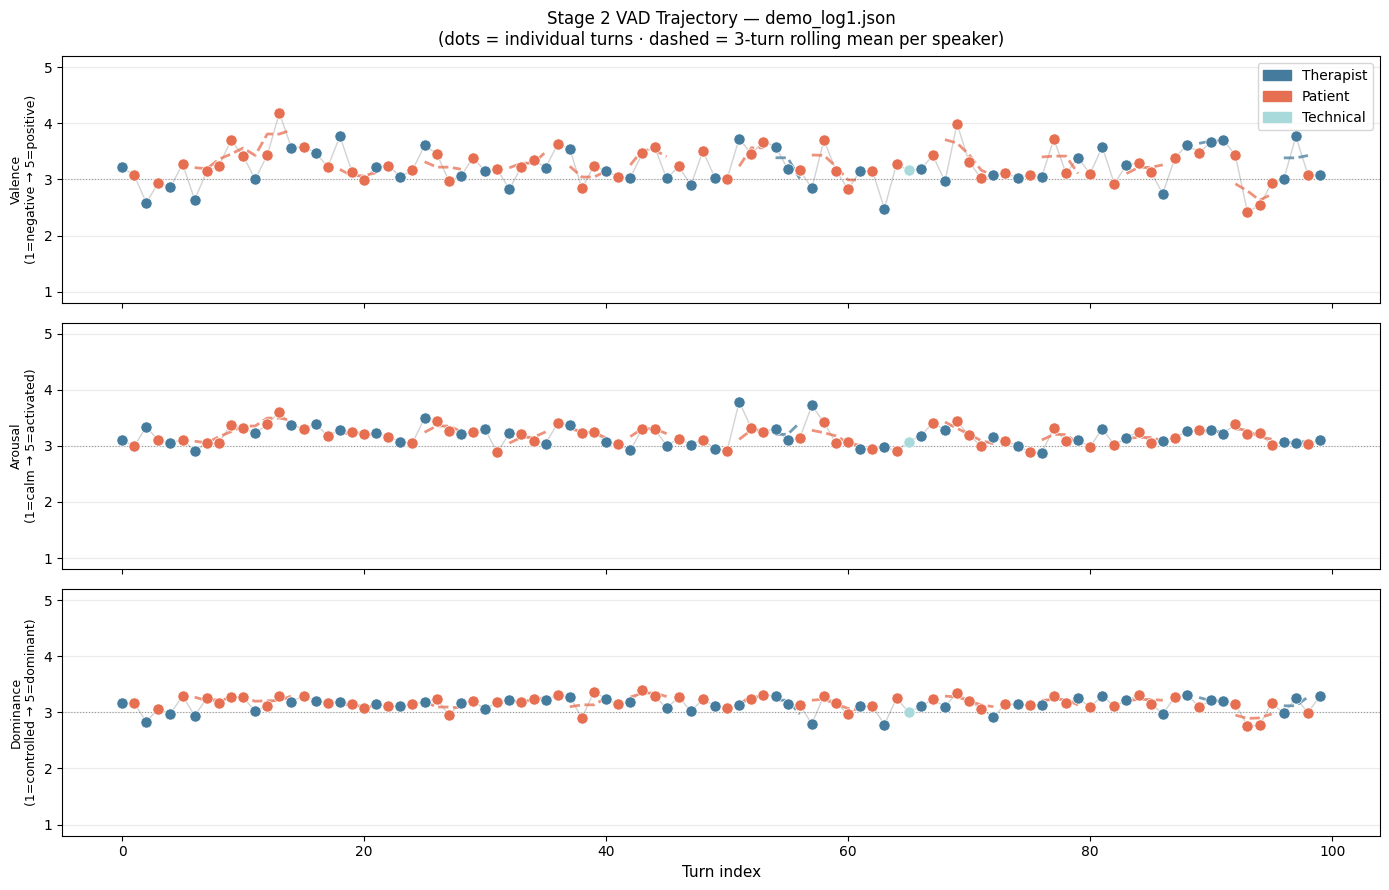

Saved .././output/demo_log1_base_vad.png


In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Load saved CSV (produced by the cell above)
df_plot = pd.read_csv(OUTPUT_DIR_PATH + "demo_log1_base_output.csv").reset_index(drop=True)
df_plot["turn"] = df_plot.index

COLORS = {"Patient": "#E76F51", "Therapist": "#457B9D", "Technical": "#A8DADC"}
dims   = ["V", "A", "D"]
ylabels = [
    "Valence\n(1=negative → 5=positive)",
    "Arousal\n(1=calm → 5=activated)",
    "Dominance\n(1=controlled → 5=dominant)",
]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, dim, ylabel in zip(axes, dims, ylabels):
    # thin grey line connecting all turns
    ax.plot(df_plot["turn"], df_plot[dim],
            color="lightgray", linewidth=1.0, zorder=1)

    # scatter dots coloured by speaker
    for speaker, grp in df_plot.groupby("speaker"):
        ax.scatter(grp["turn"], grp[dim],
                   color=COLORS.get(speaker, "gray"), label=speaker,
                   s=65, zorder=3, edgecolors="white", linewidth=0.5)

    # per-speaker 3-turn rolling mean (dashed)
    for speaker, grp in df_plot.groupby("speaker"):
        series = df_plot[dim].copy().astype(float)
        series[df_plot["speaker"] != speaker] = np.nan
        roll = series.rolling(3, min_periods=2, center=True).mean()
        ax.plot(df_plot["turn"], roll,
                color=COLORS.get(speaker, "gray"), linewidth=2.0,
                linestyle="--", alpha=0.75, zorder=2)

    # neutral reference
    ax.axhline(3.0, color="black", linestyle=":", linewidth=0.8, alpha=0.35)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("Turn index", fontsize=11)
axes[0].set_title(
    "Stage 2 VAD Trajectory — demo_log1.json\n"
    "(dots = individual turns · dashed = 3-turn rolling mean per speaker)",
    fontsize=12, pad=8)

present_speakers = df_plot["speaker"].unique()
handles = [mpatches.Patch(color=COLORS.get(s, "gray"), label=s)
           for s in present_speakers]
axes[0].legend(handles=handles, loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR_PATH + "demo_log1_base_vad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved " + OUTPUT_DIR_PATH + "demo_log1_base_vad.png")


### Patient-only VAD Trajectory

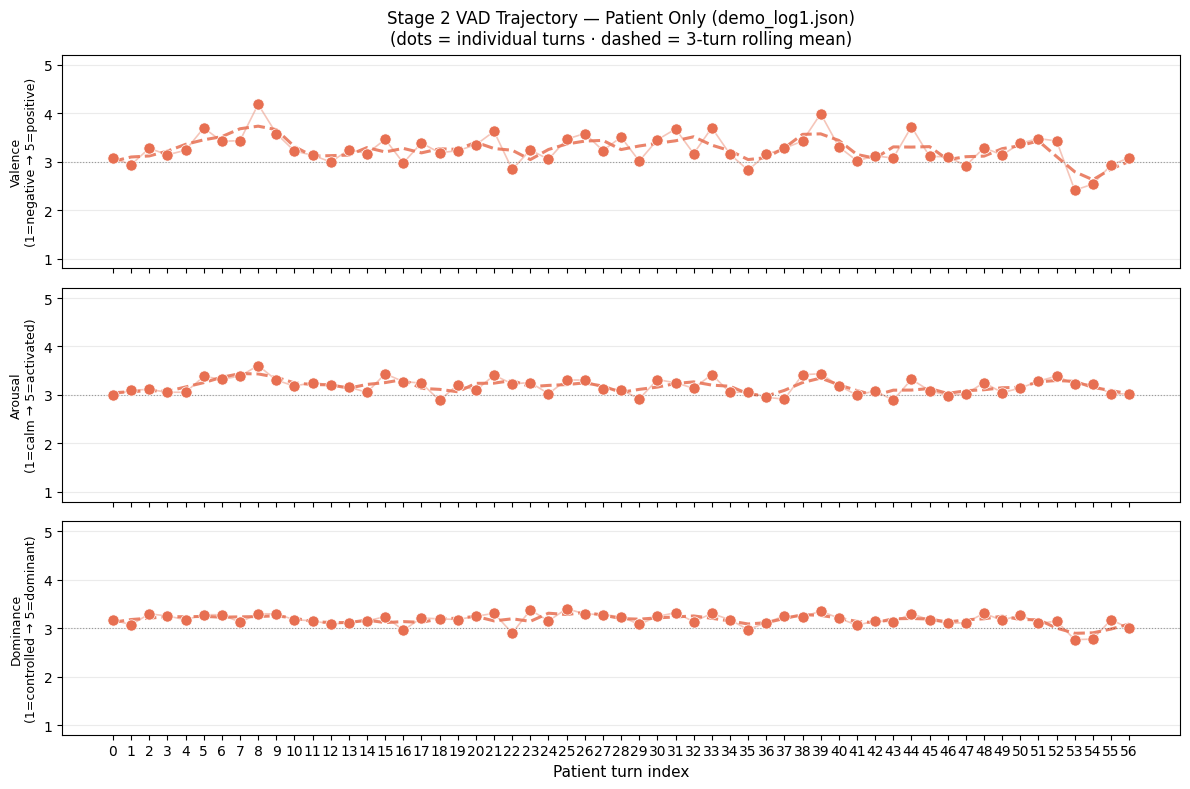

Saved .././output/demo_log1_base_patient_vad.png


In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_patient = pd.read_csv(OUTPUT_DIR_PATH + "demo_log1_base_output.csv")
df_patient = df_patient[df_patient["speaker"] == "Patient"].reset_index(drop=True)
df_patient["turn"] = df_patient.index

COLOR   = "#E76F51"
dims    = ["V", "A", "D"]
ylabels = [
    "Valence\n(1=negative → 5=positive)",
    "Arousal\n(1=calm → 5=activated)",
    "Dominance\n(1=controlled → 5=dominant)",
]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, dim, ylabel in zip(axes, dims, ylabels):
    ax.plot(df_patient["turn"], df_patient[dim],
            color=COLOR, linewidth=1.2, alpha=0.4, zorder=1)
    ax.scatter(df_patient["turn"], df_patient[dim],
               color=COLOR, s=65, zorder=3,
               edgecolors="white", linewidth=0.5)
    roll = df_patient[dim].rolling(3, min_periods=2, center=True).mean()
    ax.plot(df_patient["turn"], roll,
            color=COLOR, linewidth=2.2, linestyle="--", alpha=0.85, zorder=2)
    ax.axhline(3.0, color="black", linestyle=":", linewidth=0.8, alpha=0.35)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("Patient turn index", fontsize=11)
axes[-1].set_xticks(df_patient["turn"])
axes[0].set_title(
    "Stage 2 VAD Trajectory — Patient Only (demo_log1.json)\n"
    "(dots = individual turns · dashed = 3-turn rolling mean)",
    fontsize=12, pad=8,
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR_PATH + "demo_log1_base_patient_vad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved " + OUTPUT_DIR_PATH + "demo_log1_base_patient_vad.png")


In [6]:
# print peak VAD turns for patient
print("\nPatient turns with highest Valence:")
print(df_patient.sort_values("V", ascending=False)[["turn", "text", "V"]].head(3).to_string(index=False))

print("\nPatient turns with highest Arousal:")
print(df_patient.sort_values("A", ascending=False)[["turn", "text", "A"]].head(3).to_string(index=False))

print("\nPatient turns with highest Dominance:")
print(df_patient.sort_values("D", ascending=False)[["turn", "text", "D"]].head(3).to_string(index=False))


Client turns with highest Valence:
 turn                                                                    text     V
    8 because if i if if i truly was worthless then i would need to be with … 3.574
   18                           i can do that okay cool i can totally do that 3.302
   10                                   um hmm well i i have a friend in mind 3.187

Client turns with highest Arousal:
 turn                                                                    text     A
    6 i don't feel if you would have asked me three minutes ago or four minu… 3.535
    8 because if i if if i truly was worthless then i would need to be with … 3.518
    9 yes okay i'm always forever for as long as i can remember constantly m… 3.257

Client turns with highest Dominance:
 turn                                                                    text     D
   18                           i can do that okay cool i can totally do that 3.309
    8 because if i if if i truly was worthless the

In [7]:
# print lowest VAD turns for patient
print("\nPatient turns with lowest Valence:")
print(df_patient.sort_values("V", ascending=True)[["turn", "text", "V"]].head(3).to_string(index=False))

print("\nPatient turns with lowest Arousal:")
print(df_patient.sort_values("A", ascending=True)[["turn", "text", "A"]].head(3).to_string(index=False))

print("\nPatient turns with lowest Dominance:")
print(df_patient.sort_values("D", ascending=True)[["turn", "text", "D"]].head(3).to_string(index=False))


Client turns with lowest Valence:
 turn                                                                    text     V
    6 i don't feel if you would have asked me three minutes ago or four minu… 2.075
    1 well i look around at my friends and my family who are in relationship… 2.160
    0 i uh recently broke up with a long long-term partner and it's been one… 2.218

Client turns with lowest Arousal:
 turn                                text     A
   11         ten ten more than ten years 2.796
   14        um i mean maybe i don't know 2.854
   13 well i mean i think it will go fine 2.917

Client turns with lowest Dominance:
 turn                                                                    text     D
    1 well i look around at my friends and my family who are in relationship… 2.600
    0 i uh recently broke up with a long long-term partner and it's been one… 2.666
    2 well on one hand it means that nobody i on one hand it means that peop… 2.799


### Therapist-only VAD Trajectory

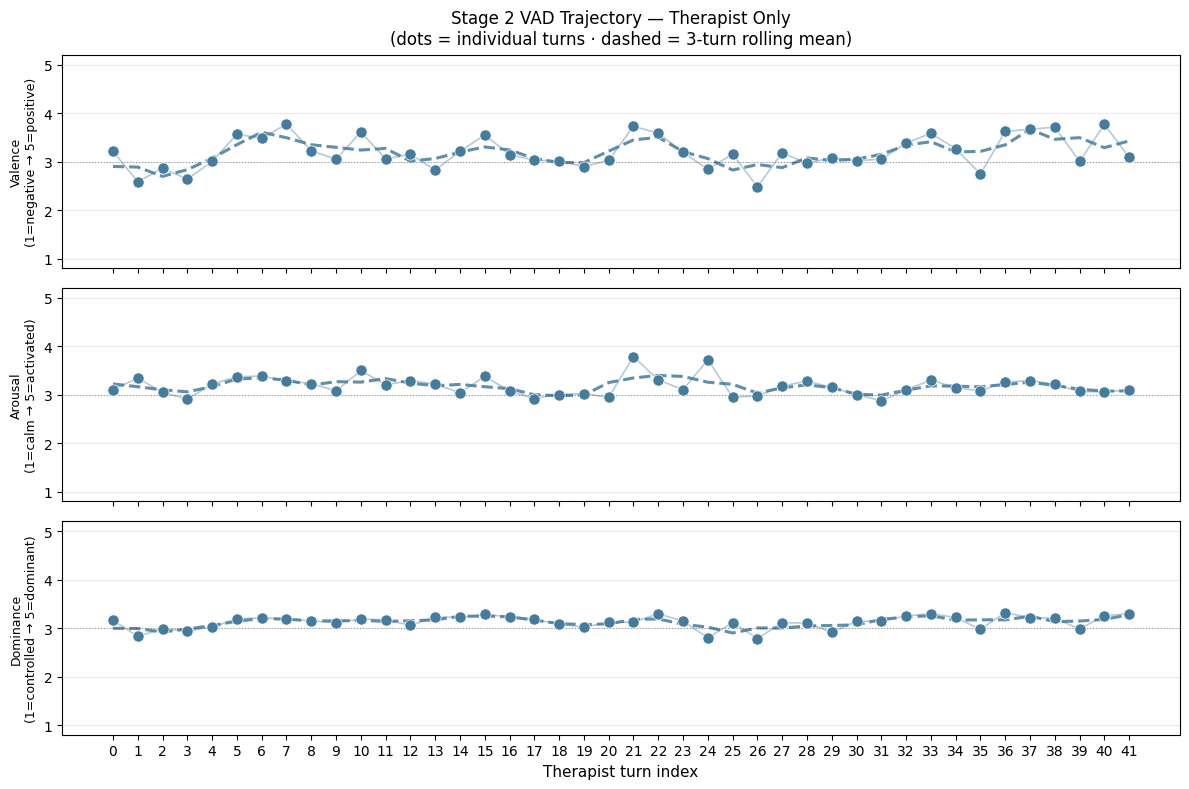

Saved .././output/demo_log1_base_therapist_vad.png


In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_therapist = pd.read_csv(OUTPUT_DIR_PATH + "demo_log1_base_output.csv")
df_therapist = df_therapist[df_therapist["speaker"] == "Therapist"].reset_index(drop=True)
df_therapist["turn"] = df_therapist.index

COLOR   = "#457B9D"
dims    = ["V", "A", "D"]
ylabels = [
    "Valence\n(1=negative → 5=positive)",
    "Arousal\n(1=calm → 5=activated)",
    "Dominance\n(1=controlled → 5=dominant)",
]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, dim, ylabel in zip(axes, dims, ylabels):
    ax.plot(df_therapist["turn"], df_therapist[dim],
            color=COLOR, linewidth=1.2, alpha=0.4, zorder=1)
    ax.scatter(df_therapist["turn"], df_therapist[dim],
               color=COLOR, s=65, zorder=3,
               edgecolors="white", linewidth=0.5)
    roll = df_therapist[dim].rolling(3, min_periods=2, center=True).mean()
    ax.plot(df_therapist["turn"], roll,
            color=COLOR, linewidth=2.2, linestyle="--", alpha=0.85, zorder=2)
    ax.axhline(3.0, color="black", linestyle=":", linewidth=0.8, alpha=0.35)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("Therapist turn index", fontsize=11)
axes[-1].set_xticks(df_therapist["turn"])
axes[0].set_title(
    "Stage 2 VAD Trajectory — Therapist Only\n"
    "(dots = individual turns · dashed = 3-turn rolling mean)",
    fontsize=12, pad=8,
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR_PATH + "demo_log1_base_therapist_vad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved " + OUTPUT_DIR_PATH + "demo_log1_base_therapist_vad.png")


In [39]:
# print peak VAD turns for therapist
print("\nTherapist turns with highest Valence:")
print(df_therapist.sort_values("V", ascending=False)[["turn", "text", "V"]].head(3).to_string(index=False))

print("\nTherapist turns with highest Arousal:")
print(df_therapist.sort_values("A", ascending=False)[["turn", "text", "A"]].head(3).to_string(index=False))

print("\nTherapist turns with highest Dominance:")
print(df_therapist.sort_values("D", ascending=False)[["turn", "text", "D"]].head(3).to_string(index=False))


Therapist turns with highest Valence:
 turn                                                                    text     V
    7                                    And the old structure was beautiful. 3.772
   40                                               I feel much more relaxed. 3.767
   21 It's a lot. If I remember correctly, we toured around the Colosseum. T… 3.730

Therapist turns with highest Arousal:
 turn                                                                    text     A
   21 It's a lot. If I remember correctly, we toured around the Colosseum. T… 3.788
   24 The specialty is that it's the smallest sovereign state in the world, … 3.722
   10 ...as a per-plate price, unless it was a formal restaurant. These were… 3.502

Therapist turns with highest Dominance:
 turn                                                                    text     D
   36 They're fine. I'm still in contact. Every time we talk, there's some '… 3.317
   41 They just pop into my head; I don't

In [40]:
# print lowest VAD turns for therapist
print("\nTherapist turns with lowest Valence:")
print(df_therapist.sort_values("V", ascending=True)[["turn", "text", "V"]].head(3).to_string(index=False))

print("\nTherapist turns with lowest Arousal:")
print(df_therapist.sort_values("A", ascending=True)[["turn", "text", "A"]].head(3).to_string(index=False))

print("\nTherapist turns with lowest Dominance:")
print(df_therapist.sort_values("D", ascending=True)[["turn", "text", "D"]].head(3).to_string(index=False))


Therapist turns with lowest Valence:
 turn                                                             text     V
   26 It's clear now. It's back. Okay, I'm sorry for the interruption. 2.480
    1 Oh, the sound is gone, right? Okay, can you hear me clearly now? 2.585
    3                         Okay. So I wasn't sure if it's okay now. 2.639

Therapist turns with lowest Arousal:
 turn                                                                    text     A
   31                       I see. So normally they don't use it much, right? 2.876
    3                                Okay. So I wasn't sure if it's okay now. 2.913
   17 ...we just say how many slices we want, then they weigh it and calcula… 2.923

Therapist turns with lowest Dominance:
 turn                                                                    text     D
   26        It's clear now. It's back. Okay, I'm sorry for the interruption. 2.784
   24 The specialty is that it's the smallest sovereign state in the wor

# Transcript Test — log_002_annotated.json (Stage 2)

Run `BertForVADRegression` on every turn in `log_002_annotated.json`.  
Text is Thai — XLM-RoBERTa handles it directly (no translation needed).  
Turns with `flag=1` mark audio/transcription issues and are highlighted in plots.

In [52]:
import json

# ── Load transcript ────────────────────────────────────────────────────────────
with open("data/log_002_annotated.json") as f:
    transcript_002 = json.load(f)

# ── Run Stage 2 model on every turn ───────────────────────────────────────────
rows_002 = []

model_s2.eval()
with torch.no_grad():
    for i, turn in enumerate(transcript_002):
        text = turn["text"]
        flag = turn.get("flag", None)
        enc  = tokenizer(
            text,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).to(DEVICE)

        vad = model_s2(
            enc["input_ids"], attention_mask=enc["attention_mask"]
        ).squeeze(0).cpu().numpy()

        rows_002.append({
            "turn":    i,
            "speaker": turn["speaker"],
            "text":    text[:70] + ("\u2026" if len(text) > 70 else ""),
            "V":       round(float(vad[0]), 3),
            "A":       round(float(vad[1]), 3),
            "D":       round(float(vad[2]), 3),
            "flag":    flag,
        })

df_002 = pd.DataFrame(rows_002)

# ── Sample turns (first 5) ─────────────────────────────────────────────────────
print("\n" + "=" * 52)
print("  log_002 Inference — Sample (first 5 turns)")
print("=" * 52)
with pd.option_context("display.max_colwidth", 72, "display.width", 130):
    print(df_002.head(5).to_string(index=False))

# ── Per-speaker mean VAD ───────────────────────────────────────────────────────
print("\nPer-speaker mean VAD  (EmoBank scale 1\u20135):")
print(df_002.groupby("speaker")[["V", "A", "D"]].mean().round(3))
print(f"\nFlagged turns: {df_002[df_002['flag']==1]['turn'].tolist()}")
print(f"(Full table: {len(df_002)} turns saved to CSV)")

# ── Save to CSV ────────────────────────────────────────────────────────────────
df_002.to_csv("output/log002_vad_output.csv", index=False)
print("Saved " + "output/log002_vad_output.csv")


  log_002 Inference — Sample (first 5 turns)
 turn     speaker                                                      text     V     A     D  flag
    0   Therapist แล้วช่วงนี้มันเป็นช่วงสอบหรือเปล่าคะ หรือว่ายังไม่ใช่เอ่ย 2.844 3.145 2.983     0
    1 Participant                                              ยังไม่ใช่ค่ะ 2.960 3.047 3.144     0
    2   Therapist                ก็คือยังเรียนอยู่เนอะ เรียนเรื่อยๆใช่ไหมคะ 3.077 3.022 3.177     0
    3 Participant                  ช่วงนี้ฝึกงานค่ะ ไม่ได้ลงเรียนเทอมนี้ค่ะ 2.974 2.899 2.995     0
    4   Therapist                                     ฝึกงานที่ไหนค่ะตอนนี้ 3.072 3.108 3.101     0

Per-speaker mean VAD  (EmoBank scale 1–5):
                 V      A      D
speaker                         
Participant  3.019  3.120  3.089
Therapist    3.032  3.102  3.086

Flagged turns: [6, 18, 31, 32, 33, 34, 35, 36, 37, 38, 50, 108, 119, 126, 142, 174, 193, 194, 195, 196, 197, 198, 199, 200, 204, 250]
(Full table: 251 turns saved to CSV)
Saved 

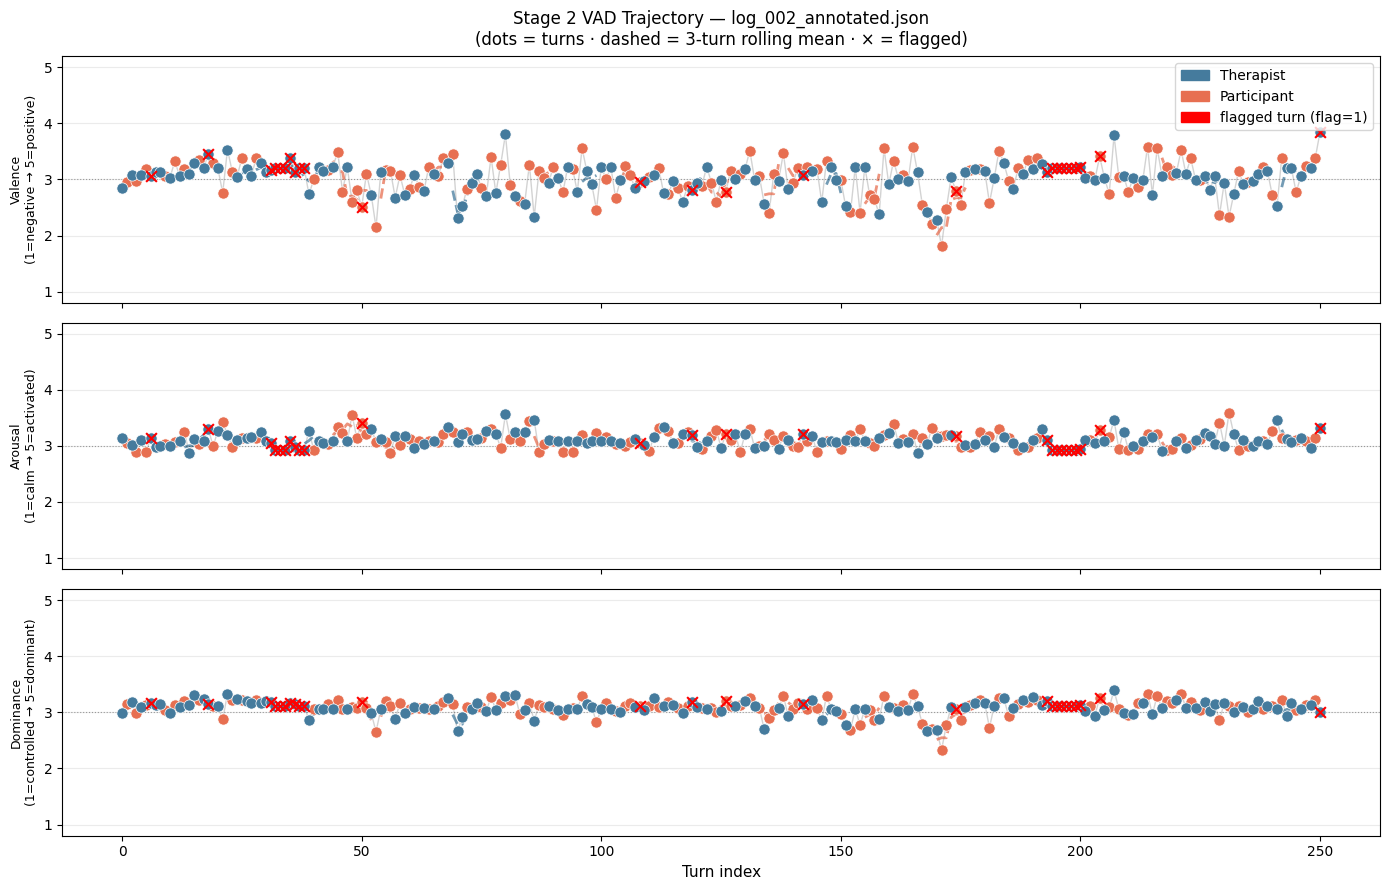

Saved output/log002_vad.png


In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df_plot_002 = pd.read_csv("output/log002_vad_output.csv").reset_index(drop=True)

COLORS_002 = {"Participant": "#E76F51", "Therapist": "#457B9D"}
dims    = ["V", "A", "D"]
ylabels = [
    "Valence\n(1=negative \u2192 5=positive)",
    "Arousal\n(1=calm \u2192 5=activated)",
    "Dominance\n(1=controlled \u2192 5=dominant)",
]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, dim, ylabel in zip(axes, dims, ylabels):
    ax.plot(df_plot_002["turn"], df_plot_002[dim],
            color="lightgray", linewidth=1.0, zorder=1)

    for speaker, grp in df_plot_002.groupby("speaker"):
        ax.scatter(grp["turn"], grp[dim],
                   color=COLORS_002.get(speaker, "gray"),
                   s=65, zorder=3, edgecolors="white", linewidth=0.5)
        series = df_plot_002[dim].copy().astype(float)
        series[df_plot_002["speaker"] != speaker] = np.nan
        roll = series.rolling(3, min_periods=2, center=True).mean()
        ax.plot(df_plot_002["turn"], roll,
                color=COLORS_002.get(speaker, "gray"), linewidth=2.0,
                linestyle="--", alpha=0.75, zorder=2)

    # mark flagged turns with a red ×
    flagged = df_plot_002[df_plot_002["flag"] == 1]
    ax.scatter(flagged["turn"], flagged[dim],
               marker="x", color="red", s=60, zorder=4,
               linewidth=1.5)

    ax.axhline(3.0, color="black", linestyle=":", linewidth=0.8, alpha=0.35)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("Turn index", fontsize=11)
axes[0].set_title(
    "Stage 2 VAD Trajectory — log_002_annotated.json\n"
    "(dots = turns · dashed = 3-turn rolling mean · \u00d7 = flagged)",
    fontsize=12, pad=8)

handles = [mpatches.Patch(color=COLORS_002.get(s, "gray"), label=s)
           for s in df_plot_002["speaker"].unique()]
handles.append(mpatches.Patch(color="red", label="flagged turn (flag=1)"))
axes[0].legend(handles=handles, loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("output/log002_vad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved " + "output/log002_vad.png")

### Participant-only VAD Trajectory

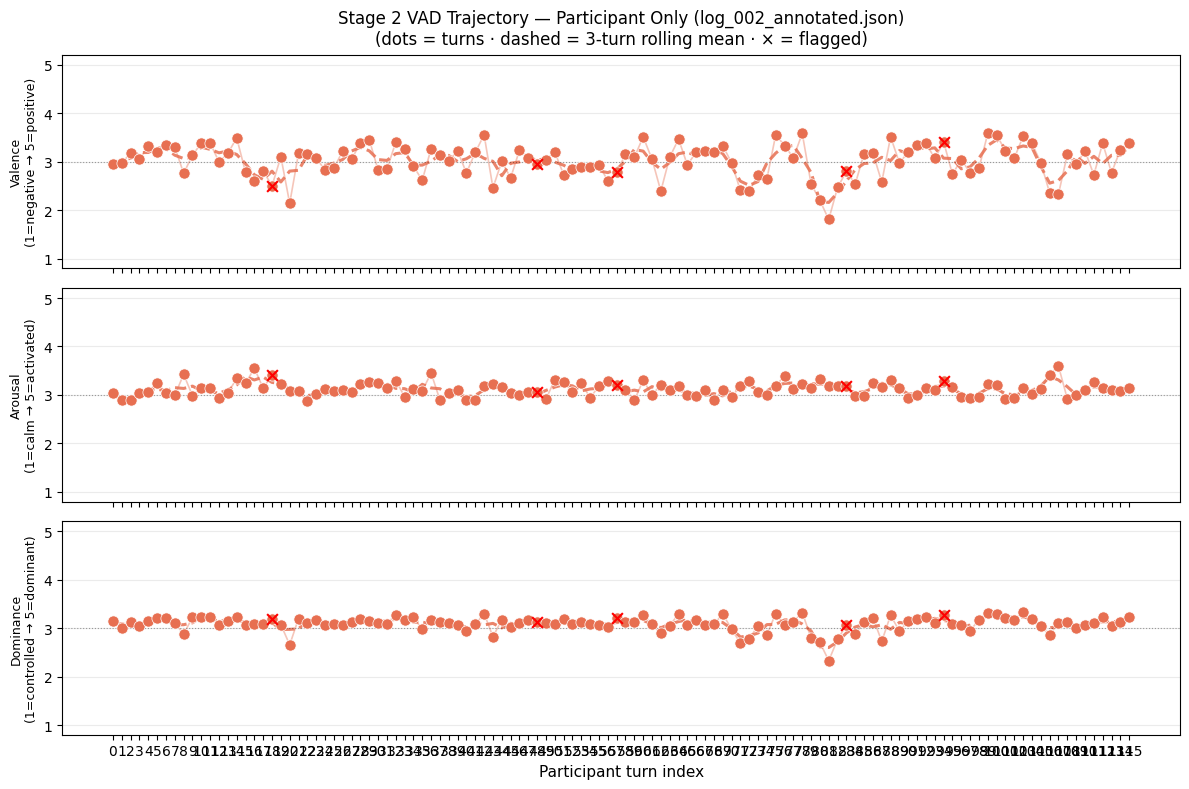

Saved output/log002_participant_vad.png


In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_002_p = pd.read_csv("output/log002_vad_output.csv")
df_002_p = df_002_p[df_002_p["speaker"] == "Participant"].reset_index(drop=True)
df_002_p["turn"] = df_002_p.index

COLOR_P = "#E76F51"
dims    = ["V", "A", "D"]
ylabels = [
    "Valence\n(1=negative \u2192 5=positive)",
    "Arousal\n(1=calm \u2192 5=activated)",
    "Dominance\n(1=controlled \u2192 5=dominant)",
]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, dim, ylabel in zip(axes, dims, ylabels):
    ax.plot(df_002_p["turn"], df_002_p[dim],
            color=COLOR_P, linewidth=1.2, alpha=0.4, zorder=1)
    ax.scatter(df_002_p["turn"], df_002_p[dim],
               color=COLOR_P, s=65, zorder=3,
               edgecolors="white", linewidth=0.5)
    roll = df_002_p[dim].rolling(3, min_periods=2, center=True).mean()
    ax.plot(df_002_p["turn"], roll,
            color=COLOR_P, linewidth=2.2, linestyle="--", alpha=0.85, zorder=2)

    flagged = df_002_p[df_002_p["flag"] == 1]
    ax.scatter(flagged["turn"], flagged[dim],
               marker="x", color="red", s=60, zorder=4, linewidth=1.5)

    ax.axhline(3.0, color="black", linestyle=":", linewidth=0.8, alpha=0.35)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("Participant turn index", fontsize=11)
axes[-1].set_xticks(df_002_p["turn"])
axes[0].set_title(
    "Stage 2 VAD Trajectory — Participant Only (log_002_annotated.json)\n"
    "(dots = turns · dashed = 3-turn rolling mean · \u00d7 = flagged)",
    fontsize=12, pad=8)

plt.tight_layout()
plt.savefig("output/log002_participant_vad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved " + "output/log002_participant_vad.png")

In [55]:
print("\nParticipant turns with highest Valence:")
print(df_002_p.sort_values("V", ascending=False)[["turn", "text", "V", "flag"]].head(3).to_string(index=False))

print("\nParticipant turns with highest Arousal:")
print(df_002_p.sort_values("A", ascending=False)[["turn", "text", "A", "flag"]].head(3).to_string(index=False))

print("\nParticipant turns with highest Dominance:")
print(df_002_p.sort_values("D", ascending=False)[["turn", "text", "D", "flag"]].head(3).to_string(index=False))

print("\nParticipant turns with lowest Valence:")
print(df_002_p.sort_values("V", ascending=True)[["turn", "text", "V", "flag"]].head(3).to_string(index=False))

print("\nParticipant turns with lowest Arousal:")
print(df_002_p.sort_values("A", ascending=True)[["turn", "text", "A", "flag"]].head(3).to_string(index=False))

print("\nParticipant turns with lowest Dominance:")
print(df_002_p.sort_values("D", ascending=True)[["turn", "text", "D", "flag"]].head(3).to_string(index=False))


Participant turns with highest Valence:
 turn        text     V  flag
   78      ใช่ค่ะ 3.587     0
   99      ใช่ค่ะ 3.587     0
  100 อืม ใช่ ค่ะ 3.560     0

Participant turns with highest Arousal:
 turn                                                                    text     A  flag
  107                                              อ่า โบว์ โกรธ ได้ เท่า นี้ 3.591     0
   16 เออ หายไป โบก็เลยถามแม่ว่าแบบว่าแม่แบบไอ้แฟ้มอันนี้หายไปไหนอะไรอย่างเง… 3.550     0
   36                                            อือหือ นั่นแหละที่สุดแล้วค่ะ 3.452     0

Participant turns with highest Dominance:
 turn                     text     D  flag
  103 ก็คุยงานด้วย คุยเล่นด้วย 3.332     0
   78                   ใช่ค่ะ 3.321     0
   99                   ใช่ค่ะ 3.321     0

Participant turns with lowest Valence:
 turn                                                                    text     V  flag
   81                                               ใช่ รู้สึกแบบเสียดายชีวิต 1.810     0
   

### Therapist-only VAD Trajectory

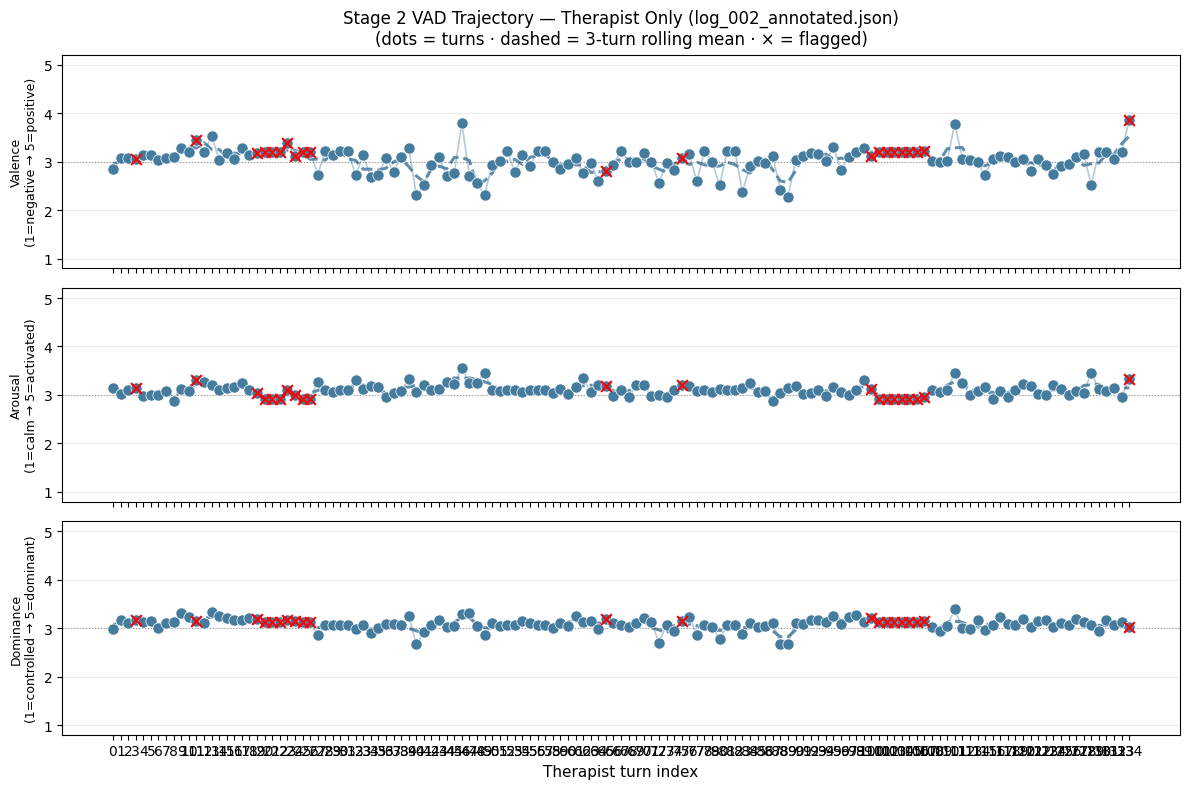

Saved output/log002_therapist_vad.png


In [56]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_002_t = pd.read_csv("output/log002_vad_output.csv")
df_002_t = df_002_t[df_002_t["speaker"] == "Therapist"].reset_index(drop=True)
df_002_t["turn"] = df_002_t.index

COLOR_T = "#457B9D"
dims    = ["V", "A", "D"]
ylabels = [
    "Valence\n(1=negative \u2192 5=positive)",
    "Arousal\n(1=calm \u2192 5=activated)",
    "Dominance\n(1=controlled \u2192 5=dominant)",
]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, dim, ylabel in zip(axes, dims, ylabels):
    ax.plot(df_002_t["turn"], df_002_t[dim],
            color=COLOR_T, linewidth=1.2, alpha=0.4, zorder=1)
    ax.scatter(df_002_t["turn"], df_002_t[dim],
               color=COLOR_T, s=65, zorder=3,
               edgecolors="white", linewidth=0.5)
    roll = df_002_t[dim].rolling(3, min_periods=2, center=True).mean()
    ax.plot(df_002_t["turn"], roll,
            color=COLOR_T, linewidth=2.2, linestyle="--", alpha=0.85, zorder=2)

    flagged = df_002_t[df_002_t["flag"] == 1]
    ax.scatter(flagged["turn"], flagged[dim],
               marker="x", color="red", s=60, zorder=4, linewidth=1.5)

    ax.axhline(3.0, color="black", linestyle=":", linewidth=0.8, alpha=0.35)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("Therapist turn index", fontsize=11)
axes[-1].set_xticks(df_002_t["turn"])
axes[0].set_title(
    "Stage 2 VAD Trajectory — Therapist Only (log_002_annotated.json)\n"
    "(dots = turns · dashed = 3-turn rolling mean · \u00d7 = flagged)",
    fontsize=12, pad=8)

plt.tight_layout()
plt.savefig("output/log002_therapist_vad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved " + "output/log002_therapist_vad.png")

In [51]:
print("\nTherapist turns with highest Valence:")
print(df_002_t.sort_values("V", ascending=False)[["turn", "text", "V", "flag"]].head(3).to_string(index=False))

print("\nTherapist turns with highest Arousal:")
print(df_002_t.sort_values("A", ascending=False)[["turn", "text", "A", "flag"]].head(3).to_string(index=False))

print("\nTherapist turns with highest Dominance:")
print(df_002_t.sort_values("D", ascending=False)[["turn", "text", "D", "flag"]].head(3).to_string(index=False))

print("\nTherapist turns with lowest Valence:")
print(df_002_t.sort_values("V", ascending=True)[["turn", "text", "V", "flag"]].head(3).to_string(index=False))

print("\nTherapist turns with lowest Arousal:")
print(df_002_t.sort_values("A", ascending=True)[["turn", "text", "A", "flag"]].head(3).to_string(index=False))

print("\nTherapist turns with lowest Dominance:")
print(df_002_t.sort_values("D", ascending=True)[["turn", "text", "D", "flag"]].head(3).to_string(index=False))


Therapist turns with highest Valence:
 turn                                                                    text     V  flag
   33 แต่โฮสต์ใจดีมากเลยนะคะ แบบ ใจดีมาก เขาเขาดูรักแล้วก็แล้วก็แบบเหมือนเทค… 3.702     0
   26 โด่งแก่ด้วย อะไรอย่างงี้ อ่า โอเคค่ะ เหมือนหลายหลายอย่างดึงให้เรารู้สึ… 3.700     1
   14 น่าสนใจ อย่่าสนใจ ที่ไทยคือยังยังไม่เคยเจอร้านไหนที่เป็นรสชาติเดียวกับ… 3.446     1

Therapist turns with highest Arousal:
 turn                                                                    text     A  flag
   14 น่าสนใจ อย่่าสนใจ ที่ไทยคือยังยังไม่เคยเจอร้านไหนที่เป็นรสชาติเดียวกับ… 3.454     1
   26 โด่งแก่ด้วย อะไรอย่างงี้ อ่า โอเคค่ะ เหมือนหลายหลายอย่างดึงให้เรารู้สึ… 3.448     1
    4 ได้ ครับ มันเหมือนเป็นประสบการณ์ที่ที่มันมีหลายสิ่งหลายอย่างเกิดขึ้นเล… 3.402     0

Therapist turns with highest Dominance:
 turn                                                                    text     D  flag
   33 แต่โฮสต์ใจดีมากเลยนะคะ แบบ ใจดีมาก เขาเขาดูรักแล้วก็แล้วก็แบบเหมื

# Client (Participant) Emotion Shift Analysis — Turn 188 boundary

Manually identified shift point: transcript turn **188** (`speaker: "Therapist"`,
text `"อ่า อ่านจบแล้วบอกพี่นะ"`).

Compares Participant-only VAD (Valence/Arousal/Dominance) **before** (`turn < 188`) vs.
**after** (`turn > 188`) this point. Reuses the VAD scores already computed in
`output/log002_vad_output.csv` — no model re-inference. Turns with `flag == 1`
(ASR/transcription artifacts) are excluded from the stats, consistent with how flagged
turns are treated elsewhere in this notebook.


In [38]:
from scipy.stats import ttest_ind, mannwhitneyu

OUTPUT_DIR_PATH = "output/"
SHIFT_TURN = 188

df_shift = pd.read_csv(OUTPUT_DIR_PATH + "log002_vad_output.csv")
df_shift = df_shift[df_shift["speaker"] == "Participant"]

n_total_before = (df_shift["turn"] < SHIFT_TURN).sum()
n_total_after  = (df_shift["turn"] > SHIFT_TURN).sum()

df_shift_clean = df_shift[df_shift["flag"] == 0]
before = df_shift_clean[df_shift_clean["turn"] < SHIFT_TURN]
after  = df_shift_clean[df_shift_clean["turn"] > SHIFT_TURN]

print(f"Participant turns before {SHIFT_TURN}: {len(before)} "
      f"(excluded {n_total_before - len(before)} flagged of {n_total_before})")
print(f"Participant turns after  {SHIFT_TURN}: {len(after)} "
      f"(excluded {n_total_after - len(after)} flagged of {n_total_after})")

rows = []
for dim in ["V", "A", "D"]:
    b, a = before[dim].to_numpy(), after[dim].to_numpy()
    t_stat, t_p = ttest_ind(b, a, equal_var=False)
    u_stat, u_p = mannwhitneyu(b, a, alternative="two-sided")
    pooled_std  = np.sqrt(((len(b) - 1) * b.std(ddof=1) ** 2 +
                            (len(a) - 1) * a.std(ddof=1) ** 2) / (len(b) + len(a) - 2))
    cohens_d    = (a.mean() - b.mean()) / pooled_std
    rows.append({
        "dim":          dim,
        "mean_before":  round(b.mean(), 3),
        "std_before":   round(b.std(ddof=1), 3),
        "n_before":     len(b),
        "mean_after":   round(a.mean(), 3),
        "std_after":    round(a.std(ddof=1), 3),
        "n_after":      len(a),
        "delta_mean":   round(a.mean() - b.mean(), 3),
        "t_stat":       round(t_stat, 3),
        "t_pvalue":     round(t_p, 4),
        "cohens_d":     round(cohens_d, 3),
        "u_stat":       round(u_stat, 3),
        "u_pvalue":     round(u_p, 4),
    })

df_shift_stats = pd.DataFrame(rows)

print("\n" + "=" * 90)
print("  Participant VAD — Before vs. After Turn 188 (flag==0 only)")
print("=" * 90)
with pd.option_context("display.width", 130):
    print(df_shift_stats.to_string(index=False))


Participant turns before 188: 87 (excluded 4 flagged of 91)
Participant turns after  188: 24 (excluded 1 flagged of 25)

  Participant VAD — Before vs. After Turn 188 (flag==0 only)
dim  mean_before  std_before  n_before  mean_after  std_after  n_after  delta_mean  t_stat  t_pvalue  cohens_d  u_stat  u_pvalue
  V        3.008       0.322        87       3.072      0.399       24       0.064  -0.722    0.4758     0.188   888.0    0.2653
  A        3.045       0.112        87       3.097      0.194       24       0.052  -1.268    0.2156     0.392   927.0    0.4039
  D        3.061       0.159        87       3.160      0.136       24       0.099  -3.030    0.0042     0.640   671.0    0.0076


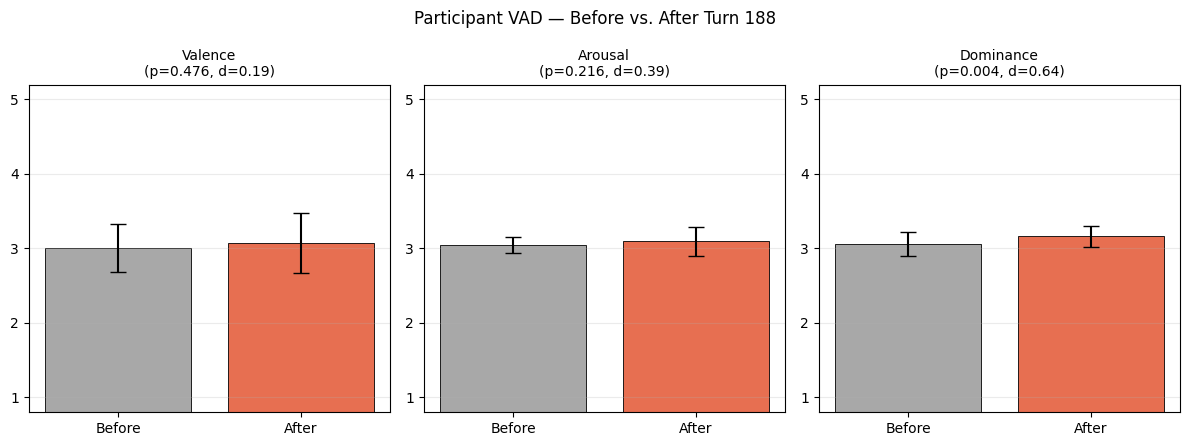

Saved output/log002_participant_shift_bars.png


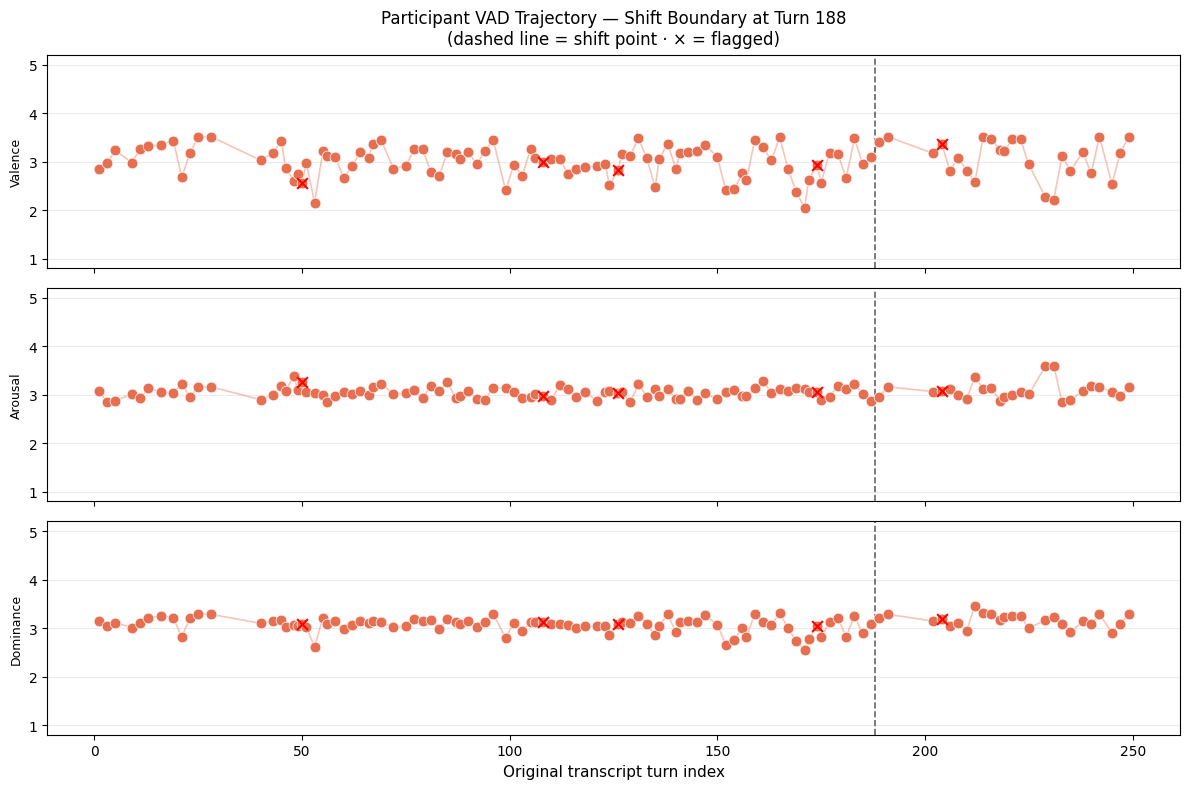

Saved output/log002_participant_shift_trajectory.png


In [39]:
import matplotlib.pyplot as plt
import numpy as np

dims    = ["V", "A", "D"]
ylabels = ["Valence", "Arousal", "Dominance"]

# ── Bar chart: before vs. after mean VAD ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
for ax, dim, ylabel in zip(axes, dims, ylabels):
    row = df_shift_stats[df_shift_stats["dim"] == dim].iloc[0]
    means = [row["mean_before"], row["mean_after"]]
    stds  = [row["std_before"], row["std_after"]]
    ax.bar(["Before", "After"], means, yerr=stds, capsize=6,
           color=["#A8A8A8", "#E76F51"], edgecolor="black", linewidth=0.6)
    ax.set_title(f"{ylabel}\n(p={row['t_pvalue']:.3f}, d={row['cohens_d']:.2f})", fontsize=10)
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Participant VAD — Before vs. After Turn 188", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR_PATH + "log002_participant_shift_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved " + OUTPUT_DIR_PATH + "log002_participant_shift_bars.png")

# ── Trajectory plot with shift boundary marked ────────────────────────────────
df_traj = pd.read_csv(OUTPUT_DIR_PATH + "log002_vad_output.csv")
df_traj = df_traj[df_traj["speaker"] == "Participant"].reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, dim, ylabel in zip(axes, dims, ylabels):
    ax.plot(df_traj["turn"], df_traj[dim], color="#E76F51", linewidth=1.2, alpha=0.4, zorder=1)
    ax.scatter(df_traj["turn"], df_traj[dim], color="#E76F51", s=60, zorder=3,
               edgecolors="white", linewidth=0.5)
    flagged = df_traj[df_traj["flag"] == 1]
    ax.scatter(flagged["turn"], flagged[dim], marker="x", color="red", s=60, zorder=4, linewidth=1.5)
    ax.axvline(SHIFT_TURN, color="black", linestyle="--", linewidth=1.2, alpha=0.6)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0.8, 5.2)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.grid(axis="y", alpha=0.25)

axes[-1].set_xlabel("Original transcript turn index", fontsize=11)
axes[0].set_title(
    f"Participant VAD Trajectory — Shift Boundary at Turn {SHIFT_TURN}\n"
    "(dashed line = shift point · \u00d7 = flagged)",
    fontsize=12, pad=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR_PATH + "log002_participant_shift_trajectory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved " + OUTPUT_DIR_PATH + "log002_participant_shift_trajectory.png")


In [40]:
df_shift_stats.to_csv(OUTPUT_DIR_PATH + "log002_participant_shift_stats.csv", index=False)
print("Saved " + OUTPUT_DIR_PATH + "log002_participant_shift_stats.csv")


Saved output/log002_participant_shift_stats.csv
